In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [14]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [16]:
df.shape

(2640, 12)

In [17]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [18]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [21]:
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Sreeja Reddy\AppData\Local\Temp\ipykernel_6284\1922139920.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Sreeja Reddy\AppData\Local\Temp\ipykernel_6284\1922139920.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

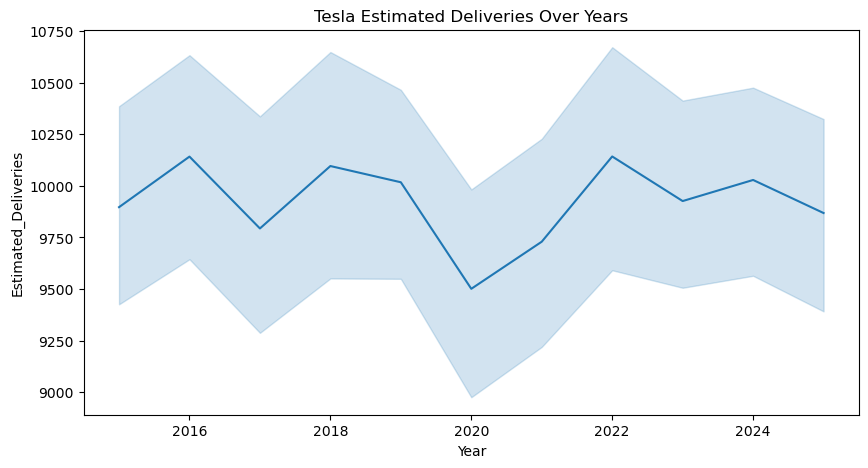

In [22]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)
plt.title('Tesla Estimated Deliveries Over Years')
plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Region', 'Model', 'Source_Type']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [24]:
df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df['Cost_Per_KM'] = (
    df['Avg_Price_USD'] / df['Range_km']
)

In [25]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Production_Efficiency,Cost_Per_KM
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984600,131.923679
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911864,142.022032
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915334,245.598583
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896594,125.414199
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914087,173.747020


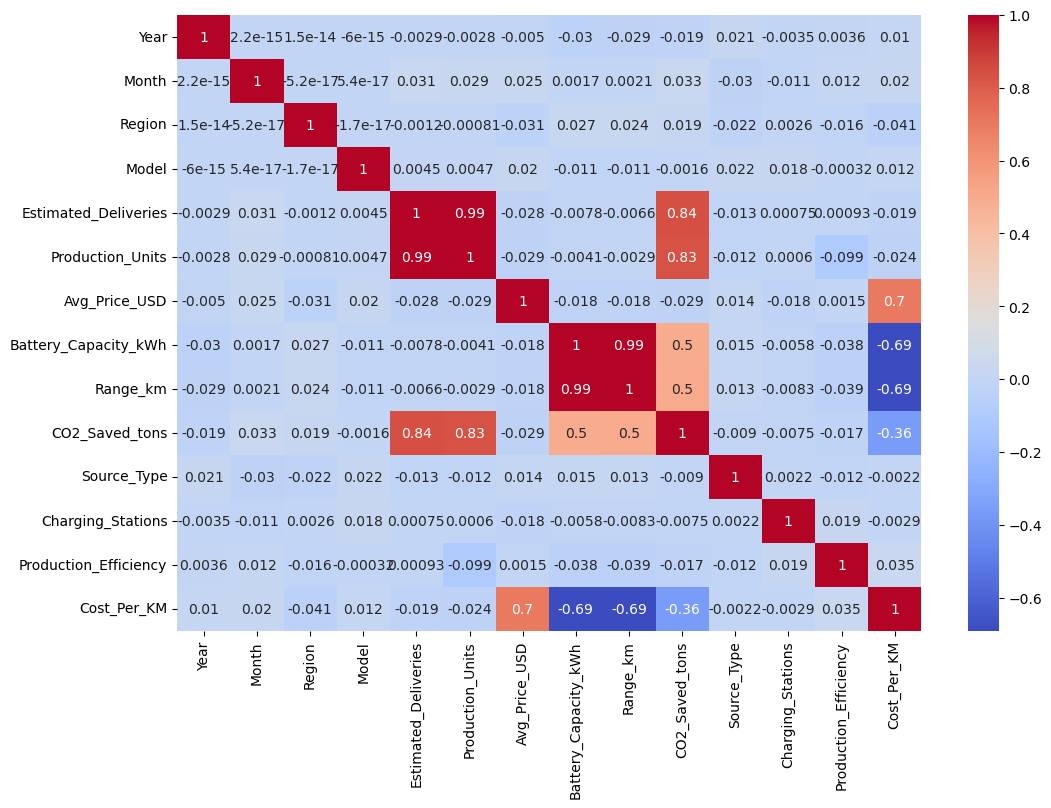

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [27]:
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

In [28]:
print(X.shape)
print(y.shape)

(2640, 13)
(2640,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [31]:
pred = rf.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 66.67832386363636
RMSE: 113.13048804262829
R2 Score: 0.9991414021244013


In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                  Feature  Importance
4        Production_Units    0.990293
11  Production_Efficiency    0.008667
8          CO2_Saved_tons    0.000176
12            Cost_Per_KM    0.000147
5           Avg_Price_USD    0.000131
1                   Month    0.000115
7                Range_km    0.000114
10      Charging_Stations    0.000096
0                    Year    0.000081
3                   Model    0.000056
2                  Region    0.000053
9             Source_Type    0.000050
6    Battery_Capacity_kWh    0.000020


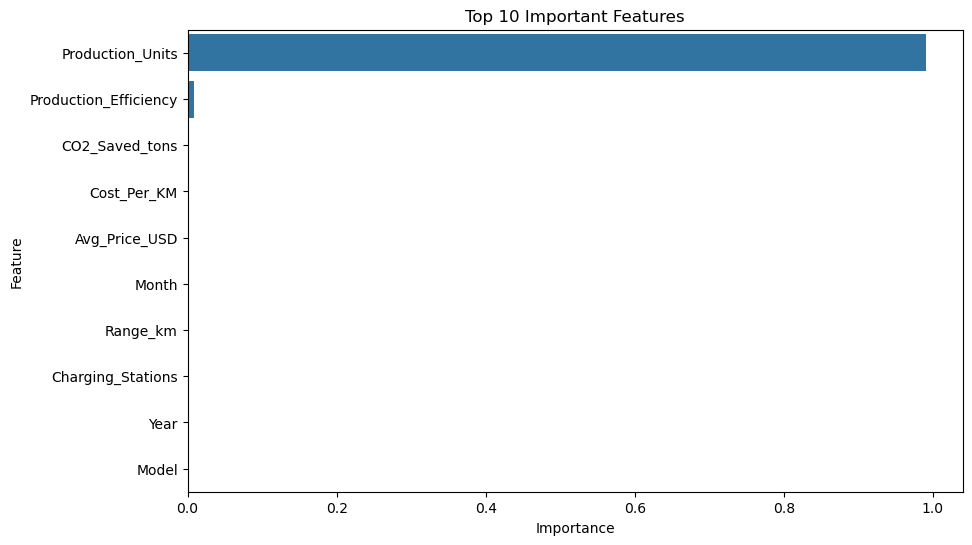

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [36]:
print("Gradient Boosting Results")

print("MAE :", mean_absolute_error(y_test, gb_pred))

print("RMSE :", np.sqrt(
    mean_squared_error(y_test, gb_pred)
))

print("R2 :", r2_score(y_test, gb_pred))

Gradient Boosting Results
MAE : 71.74449604950271
RMSE : 99.77889398447729
R2 : 0.9993321055117554


In [37]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15]
}

grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [38]:
print(grid.best_params_)

{'max_depth': 15, 'n_estimators': 200}


In [39]:
best_model = grid.best_estimator_

In [40]:
best_pred = best_model.predict(X_test)

print("Tuned Random Forest")

print("MAE :", mean_absolute_error(
    y_test,
    best_pred
))

print("RMSE :", np.sqrt(
    mean_squared_error(
        y_test,
        best_pred
    )
))

print("R2 :", r2_score(
    y_test,
    best_pred
))

Tuned Random Forest
MAE : 66.22124136112205
RMSE : 110.68980294942972
R2 : 0.9991780493998917


In [41]:
import joblib

joblib.dump(
    best_model,
    "tesla_forecasting_model.pkl"
)

print("Model Saved Successfully")


Model Saved Successfully


In [42]:
sample = X.iloc[[0]]

prediction = best_model.predict(sample)

print(
    "Predicted Deliveries:",
    prediction[0]
)

Predicted Deliveries: 17568.965


# Conclusion

- Performed data cleaning and preprocessing.
- Conducted exploratory data analysis on Tesla deliveries and production data.
- Applied feature engineering techniques.
- Trained Linear Regression, Random Forest, and Gradient Boosting models.
- Tuned Random Forest using GridSearchCV.
- Evaluated models using MAE, RMSE, and R² Score.
- Saved the best-performing model for future deployment.

In [43]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, pred),
        r2_score(y_test, gb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ]
})

results

,Model,R2 Score,RMSE
0,Random Forest,0.999141,113.130488
1,Gradient Boosting,0.999332,99.778894


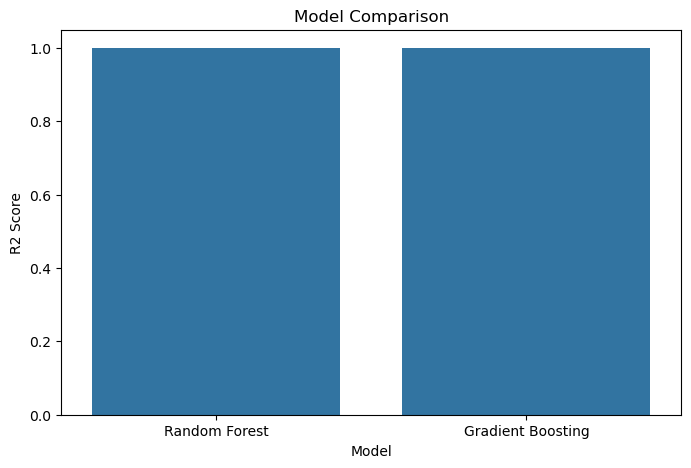

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison")
plt.show()